# 03. Modelagem e Avaliação

In [23]:
import sys
import warnings

sys.path.append('./src')

import numpy as np
import pandas as pd
import scipy.sparse as sp

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

from xgboost import XGBClassifier
import umap

import optuna

from preprocessing import carregar_e_limpar, obter_ou_criar_split
from avaliacao import (
    avaliar_modelo,
    comparar_modelos_bootstrap,
    top_features_por_classe,
    pr_auc_macro,
)
from modelagem import construir_modelos_candidatos, rodar_grade_comparativa

warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [24]:
df = carregar_e_limpar('data/raw/dataset_ecommerce.csv')

le = LabelEncoder()
y = le.fit_transform(df['categoria'])

idx_train, idx_test = obter_ou_criar_split(df, y, caminho_split='data/processed/split.npz', test_size=0.2, random_state=42)
y_train, y_test = y[idx_train], y[idx_test]
texto_train = df['texto'].to_numpy(dtype=object)[idx_train]  
texto_test = df['texto'].to_numpy(dtype=object)[idx_test]

print(f"Treino: {len(idx_train)} | Teste: {len(idx_test)}")

Treino: 22241 | Teste: 5561


## 1. Baseline

Antes de treinar qualquer modelo de verdade, vale estabelecer uma referência simples: prever sempre a classe majoritária. Um modelo só é útil na prática se conseguir superar esse baseline.

In [25]:
baseline_data = np.load('data/processed/embeddings_reducoes/pca_10.npz')
X_tr_base, X_te_base = baseline_data['X_train'], baseline_data['X_test']

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
metricas_baseline, y_pred_dummy = avaliar_modelo(
    'Baseline (classe majoritária)', dummy, X_tr_base, y_train, X_te_base, y_test
)
print("Baseline (prevê sempre a classe majoritária):")
for k, v in metricas_baseline.items():
    if k != 'modelo':
        print(f"  {k}: {v:.3f}")

Baseline (prevê sempre a classe majoritária):
  accuracy: 0.380
  balanced_accuracy: 0.250
  precision_macro: 0.095
  recall_macro: 0.250
  f1_macro: 0.138
  f1_weighted: 0.209


## 2 e 3. Modelos, PCA, UMAP e TF-IDF

Para essa comparação, foram escolhidos cinco modelos: a **Logistic Regression**, simples e linear, e quatro modelos baseados em árvores, com naturezas diferentes entre si. **Random Forest** e **Extra Trees** são exemplos de bagging, enquanto **HistGradientBoosting** e **XGBoost** são exemplos de boosting.

Foram testados os cinco modelos com as representações salvas no notebook anterior: PCA e UMAP, cada uma nas três dimensões (10, 20 e 30), e o TF-IDF, em alta dimensão (5000 palavras, sem nenhuma redução). 

In [26]:
modelos = construir_modelos_candidatos()

resultados, predicoes_cache, embeddings_cache = rodar_grade_comparativa(
    y_train, y_test, modelos=modelos
)


[AVISO] HistGradientBoosting pulado para TF-IDF (não suporta entrada esparsa).


## Tabela comparativa

In [27]:
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados[['reducao', 'dim', 'modelo', 'accuracy', 'precision_macro',
                                'recall_macro', 'f1_macro', 'f1_weighted', 'balanced_accuracy']]
df_resultados = df_resultados.sort_values('f1_macro', ascending=False).reset_index(drop=True)
df_resultados

,reducao,dim,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,balanced_accuracy
0,TF-IDF,5000,Logistic,0.947851,0.951131,0.944113,0.947447,0.947777,0.944113
1,UMAP,10,Random Forest,0.941018,0.942119,0.940461,0.940996,0.940944,0.940461
2,UMAP,20,HistGradientBoosting,0.938860,0.940185,0.937916,0.938691,0.938792,0.937916
3,UMAP,20,Random Forest,0.938320,0.939431,0.938187,0.938415,0.938247,0.938187
4,UMAP,10,Extra Trees,0.937781,0.939304,0.936813,0.937747,0.937698,0.936813
5,UMAP,10,XGBoost,0.937601,0.939395,0.936237,0.937520,0.937538,0.936237
6,UMAP,30,Random Forest,0.937421,0.938813,0.936445,0.937284,0.937350,0.936445
7,UMAP,10,HistGradientBoosting,0.937062,0.937683,0.937053,0.937070,0.937021,0.937053
8,UMAP,20,XGBoost,0.936702,0.938060,0.935568,0.936516,0.936653,0.935568
9,UMAP,30,HistGradientBoosting,0.936342,0.937989,0.935445,0.936413,0.936296,0.935445


## 4. Escolhendo as configurações para otimizar

In [28]:
melhores = (
    df_resultados
    .sort_values('f1_macro', ascending=False)
    .head(2)
    .reset_index(drop=True)
)

melhor_1 = melhores.iloc[0]
melhor_2 = melhores.iloc[1]

modelo_1, reducao_1, dim_1 = melhor_1['modelo'], melhor_1['reducao'], int(melhor_1['dim'])
modelo_2, reducao_2, dim_2 = melhor_2['modelo'], melhor_2['reducao'], int(melhor_2['dim'])

X_tr_1, X_te_1 = embeddings_cache[(reducao_1, dim_1)]
X_tr_2, X_te_2 = embeddings_cache[(reducao_2, dim_2)]

print(
    f"1º melhor: {melhor_1['modelo']} + {melhor_1['reducao']} "
    f"{int(melhor_1['dim'])}D "
    f"(F1-macro={melhor_1['f1_macro']:.3f})"
)

print(
    f"2º melhor: {melhor_2['modelo']} + {melhor_2['reducao']} "
    f"{int(melhor_2['dim'])}D "
    f"(F1-macro={melhor_2['f1_macro']:.3f})"
)

1º melhor: Logistic + TF-IDF 5000D (F1-macro=0.947)
2º melhor: Random Forest + UMAP 10D (F1-macro=0.941)


## 5. Otimização com Optuna

Para não usar o conjunto de teste durante a busca de hiperparâmetros, o que seria um vazamento de dados, foi separado uma fatia de validação dentro do próprio treino. Os mesmos índices de treino/validação são usados para os dois modelos, então a comparação entre eles fica justa.

In [29]:
idx_tr_train, idx_tr_val = train_test_split(
    np.arange(len(y_train)), test_size=0.2, random_state=42, stratify=y_train
)

y_opt_train, y_opt_val = y_train[idx_tr_train], y_train[idx_tr_val]

X_opt_train_1, X_opt_val_1 = X_tr_1[idx_tr_train], X_tr_1[idx_tr_val]
X_opt_train_2, X_opt_val_2 = X_tr_2[idx_tr_train], X_tr_2[idx_tr_val]


def otimizar_modelo(modelo, X_tr, X_val):
    def objective(trial):
        if modelo == 'XGBoost':
            m = XGBClassifier(
                n_estimators=trial.suggest_int('n_estimators', 100, 500, step=50),
                max_depth=trial.suggest_int('max_depth', 3, 10),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
                min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
                eval_metric='mlogloss', random_state=42, n_jobs=2
            )

        elif modelo == 'Logistic':
            m = LogisticRegression(
                C=trial.suggest_float('C', 1e-3, 1e2, log=True),
                class_weight=trial.suggest_categorical('class_weight', [None, 'balanced']),
                max_iter=2000, random_state=42
            )

        elif modelo == 'Random Forest':
            m = RandomForestClassifier(
                n_estimators=trial.suggest_int('n_estimators', 100, 500, step=50),
                max_depth=trial.suggest_int('max_depth', 3, 20),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 5),
                random_state=42, n_jobs=2
            )

        elif modelo == 'Extra Trees':
            m = ExtraTreesClassifier(
                n_estimators=trial.suggest_int('n_estimators', 100, 500, step=50),
                max_depth=trial.suggest_int('max_depth', 3, 20),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 5),
                random_state=42, n_jobs=2
            )

        elif modelo == 'HistGradientBoosting':
            m = HistGradientBoostingClassifier(
                max_iter=trial.suggest_int('max_iter', 100, 500, step=50),
                max_depth=trial.suggest_int('max_depth', 3, 15),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                l2_regularization=trial.suggest_float('l2_regularization', 1e-3, 10, log=True),
                random_state=42
            )

        else:
            raise ValueError(f"Modelo não suportado: {modelo}")

        m.fit(X_tr, y_opt_train)
        return f1_score(y_opt_val, m.predict(X_val), average='macro')

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=25)

    print(f"[{modelo}] Melhor F1: {study.best_value:.3f}")
    print(f"[{modelo}] Parâmetros: {study.best_params}")

    return study.best_params


melhores_params_1 = otimizar_modelo(modelo_1, X_opt_train_1, X_opt_val_1)
melhores_params_2 = otimizar_modelo(modelo_2, X_opt_train_2, X_opt_val_2)

[Logistic] Melhor F1: 0.953
[Logistic] Parâmetros: {'C': 4.549349882568909, 'class_weight': 'balanced'}
[Random Forest] Melhor F1: 0.947
[Random Forest] Parâmetros: {'n_estimators': 300, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 4}


## 6. Validação cruzada (5-fold)

Usar o X_tr_xgb ou X_tr_log já reduzido no cross_validate causaria vazamento, pois o TF-IDF/UMAP já teria usado os dados dos folds de validação.

Por isso, cada modelo finalista é colocado em um Pipeline com a representação e o modelo. Assim, em cada fold, o fit é feito apenas com os dados de treino daquele fold, evitando vazamento e deixando a validação mais confiável.


5-fold CV: Logistic (TF-IDF 5000D)
  f1_macro         média=0.946 +/- 0.003 | valores=[0.946 0.941 0.948 0.95  0.944]
  accuracy         média=0.946 +/- 0.003 | valores=[0.947 0.942 0.948 0.95  0.944]
  precision_macro  média=0.946 +/- 0.003 | valores=[0.947 0.941 0.947 0.95  0.943]
  recall_macro     média=0.946 +/- 0.003 | valores=[0.946 0.941 0.949 0.949 0.944]

5-fold CV: Random Forest (UMAP 10D)
  f1_macro         média=0.945 +/- 0.001 | valores=[0.945 0.943 0.946 0.946 0.945]
  accuracy         média=0.945 +/- 0.001 | valores=[0.946 0.943 0.946 0.946 0.945]
  precision_macro  média=0.947 +/- 0.000 | valores=[0.947 0.947 0.946 0.947 0.947]
  recall_macro     média=0.943 +/- 0.002 | valores=[0.943 0.939 0.945 0.945 0.944]


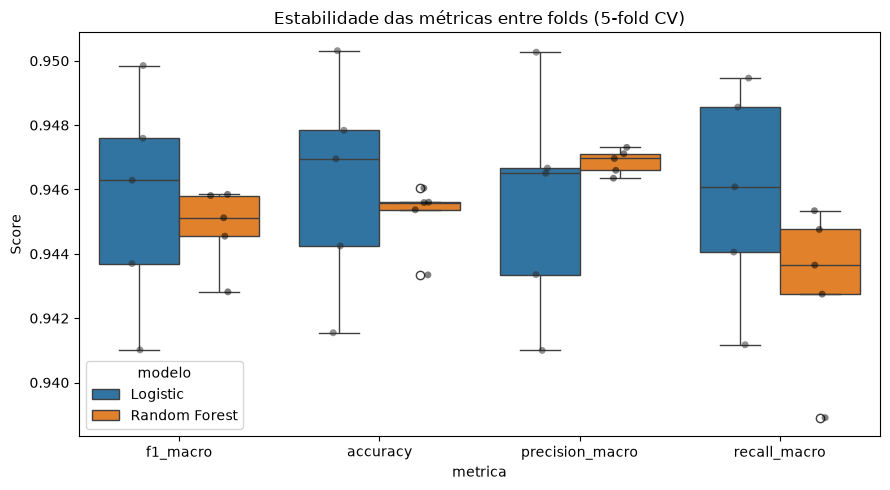

In [38]:
scoring = {
    'f1_macro': 'f1_macro',
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def criar_pipeline(modelo, reducao, dim, params):
    if reducao == 'TF-IDF':
        clf = LogisticRegression(**params) if modelo == 'Logistic' else XGBClassifier(**params)
        return Pipeline([
            ('tfidf', TfidfVectorizer(max_features=5000, min_df=2)),
            ('clf', clf)
        ])

    if modelo == 'XGBoost':
        clf = XGBClassifier(**params)
    elif modelo == 'Logistic':
        clf = LogisticRegression(**params)
    elif modelo == 'Random Forest':
        clf = RandomForestClassifier(**params)
    elif modelo == 'Extra Trees':
        clf = ExtraTreesClassifier(**params)
    elif modelo == 'HistGradientBoosting':
        clf = HistGradientBoostingClassifier(**params)
    else:
        raise ValueError(f"Modelo n\u00e3o suportado: {modelo}")

    return Pipeline([
        ('umap', umap.UMAP(n_components=dim, n_jobs=2)),
        ('clf', clf)
    ])


pipelines = [
    (modelo_1, reducao_1, dim_1, melhores_params_1, X_tr_1),
    (modelo_2, reducao_2, dim_2, melhores_params_2, X_tr_2)
]

dados_cv = []

for modelo, reducao, dim, params, X_dados in pipelines:
    pipeline = criar_pipeline(modelo, reducao, dim, params)

    if reducao == 'TF-IDF':
        dados = texto_train
    else:
        dados = X_dados

    scores = cross_validate(
        pipeline,
        dados,
        y_train,
        cv=skf,
        scoring=scoring
    )

    print(
        f"\n5-fold CV: {modelo} ({reducao} {dim}D)"
    )

    for metrica in scoring:
        vals = scores[f'test_{metrica}']
        print(
            f"  {metrica:16s} média={vals.mean():.3f} "
            f"+/- {vals.std():.3f} | valores={np.round(vals, 3)}"
        )

    resultado = pd.DataFrame({
        m: scores[f'test_{m}'] for m in scoring
    })
    resultado['modelo'] = modelo

    dados_cv.append(resultado)

dados_cv = pd.concat(dados_cv, ignore_index=True)

dados_cv_long = dados_cv.melt(
    id_vars='modelo',
    var_name='metrica',
    value_name='score'
)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=dados_cv_long,
    x='metrica',
    y='score',
    hue='modelo'
)

sns.stripplot(
    data=dados_cv_long,
    x='metrica',
    y='score',
    hue='modelo',
    dodge=True,
    color='black',
    alpha=0.5,
    legend=False
)

plt.title('Estabilidade das métricas entre folds (5-fold CV)')
plt.ylabel('Score')
plt.tight_layout()
plt.savefig('figs/03_cv_estabilidade.png', dpi=100)
plt.show()

- Logistic Regression acima do Random Forest nas 4 métricas, de forma consistente entre folds.
- Precision_macro é onde eles mais se aproximam.
- Recall_macro é onde a diferença é maior, Random Forest bem mais espalhado e mais baixo.

## 7. Avaliação final no teste

Logistic otimizado   (TF-IDF 5000D), F1 macro: 0.948 | F1 weighted: 0.948 | ROC-AUC: 0.991 | PR-AUC macro: 0.978
Random Forest otimizado   (UMAP 10D), F1 macro: 0.938 | F1 weighted: 0.938 | ROC-AUC: 0.986 | PR-AUC macro: 0.966

[Nota] O ROC-AUC dos dois modelos está muito perto de 1 e diferencia pouco entre eles. Isso é esperado num problema com boa separação entre classes como este. O PR-AUC por classe é reportado ao lado por ser mais sensível ao desbalanceamento residual entre categorias.

Vencedor: Logistic (TF-IDF 5000D), F1-macro=0.948

                      precision    recall  f1-score   support

               Books       0.94      0.93      0.94      1251
Clothing_Accessories       0.97      0.98      0.98      1135
         Electronics       0.93      0.93      0.93      1062
           Household       0.95      0.95      0.95      2113

            accuracy                           0.95      5561
           macro avg       0.95      0.95      0.95      5561
        weighted

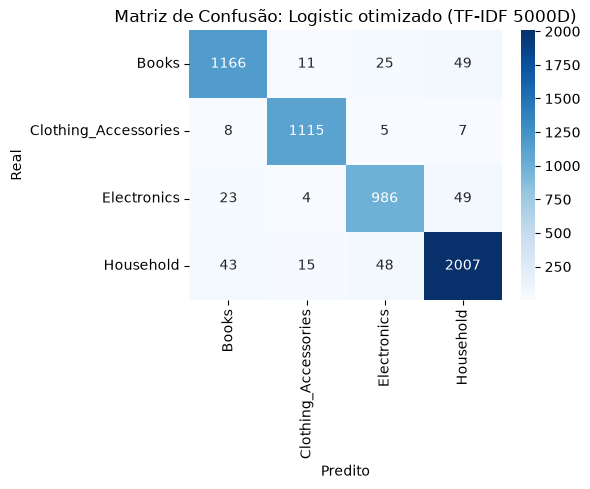

In [39]:
def construir_classificador(modelo, params):
    if modelo == 'XGBoost':
        return XGBClassifier(**params)
    elif modelo == 'Logistic':
        return LogisticRegression(**params)
    elif modelo == 'Random Forest':
        return RandomForestClassifier(**params)
    elif modelo == 'Extra Trees':
        return ExtraTreesClassifier(**params)
    elif modelo == 'HistGradientBoosting':
        return HistGradientBoostingClassifier(**params)
    else:
        raise ValueError(f"Modelo n\u00e3o suportado: {modelo}")

clf_1 = construir_classificador(modelo_1, melhores_params_1)
clf_1.fit(X_tr_1, y_train)
y_pred_1 = clf_1.predict(X_te_1)
y_proba_1 = clf_1.predict_proba(X_te_1)

f1_macro_1 = f1_score(y_test, y_pred_1, average='macro')
f1_weighted_1 = f1_score(y_test, y_pred_1, average='weighted')
roc_auc_1 = roc_auc_score(y_test, y_proba_1, multi_class='ovr', average='macro')
pr_auc_1 = pr_auc_macro(y_test, y_proba_1, le.classes_)

clf_2 = construir_classificador(modelo_2, melhores_params_2)
clf_2.fit(X_tr_2, y_train)
y_pred_2 = clf_2.predict(X_te_2)
y_proba_2 = clf_2.predict_proba(X_te_2)

f1_macro_2 = f1_score(y_test, y_pred_2, average='macro')
f1_weighted_2 = f1_score(y_test, y_pred_2, average='weighted')
roc_auc_2 = roc_auc_score(y_test, y_proba_2, multi_class='ovr', average='macro')
pr_auc_2 = pr_auc_macro(y_test, y_proba_2, le.classes_)

print(f"{modelo_1} otimizado   ({reducao_1} {dim_1}D), F1 macro: {f1_macro_1:.3f} | F1 weighted: {f1_weighted_1:.3f} | ROC-AUC: {roc_auc_1:.3f} | PR-AUC macro: {pr_auc_1['macro']:.3f}")
print(f"{modelo_2} otimizado   ({reducao_2} {dim_2}D), F1 macro: {f1_macro_2:.3f} | F1 weighted: {f1_weighted_2:.3f} | ROC-AUC: {roc_auc_2:.3f} | PR-AUC macro: {pr_auc_2['macro']:.3f}")
print("\n[Nota] O ROC-AUC dos dois modelos está muito perto de 1 e diferencia pouco entre eles. "
      "Isso é esperado num problema com boa separação entre classes como este. O PR-AUC por classe é "
      "reportado ao lado por ser mais sensível ao desbalanceamento residual entre categorias.")

if f1_macro_1 >= f1_macro_2:
    modelo_final_nome = modelo_1
    reducao_final, dim_final = reducao_1, dim_1
    params_finais = melhores_params_1
    modelo_final_obj = clf_1
    y_pred_final, y_proba_final = y_pred_1, y_proba_1
    f1_macro_final, f1_weighted_final, roc_auc_final = f1_macro_1, f1_weighted_1, roc_auc_1
else:
    modelo_final_nome = modelo_2
    reducao_final, dim_final = reducao_2, dim_2
    params_finais = melhores_params_2
    modelo_final_obj = clf_2
    y_pred_final, y_proba_final = y_pred_2, y_proba_2
    f1_macro_final, f1_weighted_final, roc_auc_final = f1_macro_2, f1_weighted_2, roc_auc_2

print(f"\nVencedor: {modelo_final_nome} ({reducao_final} {dim_final}D), F1-macro={f1_macro_final:.3f}")

print()
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusão: {modelo_final_nome} otimizado ({reducao_final} {dim_final}D)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.tight_layout()
plt.savefig('figs/03_matriz_confusao.png', dpi=100)
plt.show()

- Clothing_Accessories: quase sem erro.
- Household: mais erros em número absoluto, confunde em todas as direções.
- Electronics: maior taxa de erro relativa, confunde principalmente com Household.
- Books: erro moderado, também puxado pra Household.
- Erros concentram em torno de Household; as outras classes quase não se confundem entre si.

## 8. A diferença entre os dois finalistas é estatisticamente significativa?

A diferença de F1-macro entre os dois finalistas é pequena. Em vez de só comparar os dois números, testamos com bootstrap pareado sobre o conjunto de teste: reamostramos os mesmos índices de teste muitas vezes, recalculamos a métrica dos dois modelos em cada reamostragem e vemos se a diferença observada é maior do que se esperaria por ruído de amostragem.

In [40]:
resultado_significancia = comparar_modelos_bootstrap(
    y_test, y_pred_1, y_pred_2, metrica='f1_macro', n_boot=3000, random_state=42
)
print(f"Diferença observada ({modelo_1} − {modelo_2}) em F1-macro: {resultado_significancia['diferenca_observada']:+.4f}")
print(f"Intervalo de confiança 95% (bootstrap): [{resultado_significancia['ic_95_baixo']:+.4f}, {resultado_significancia['ic_95_alto']:+.4f}]")
print(f"p-valor (duas caudas): {resultado_significancia['p_valor']:.4f}")
if resultado_significancia['significativo_5pct']:
    print("=> A diferença é estatisticamente significativa ao nível de 5%: não é razoável atribuí-la "
          "só a ruído de amostragem no conjunto de teste.")
else:
    print("=> A diferença NÃO é estatisticamente significativa ao nível de 5%: com esse tamanho de "
          "teste, não dá para descartar que o resultado seja ruído de amostragem, e os dois modelos "
          "deveriam ser considerados estatisticamente equivalentes nesta métrica.")

Diferença observada (Logistic − Random Forest) em F1-macro: +0.0096
Intervalo de confiança 95% (bootstrap): [+0.0035, +0.0154]
p-valor (duas caudas): 0.0020
=> A diferença é estatisticamente significativa ao nível de 5%: não é razoável atribuí-la só a ruído de amostragem no conjunto de teste.


## 9. Análise dos erros

In [41]:
erros = pd.DataFrame({
    'texto': [t[:120] for t in texto_test],
    'categoria_real': le.inverse_transform(y_test),
    'categoria_prevista': le.inverse_transform(y_pred_final),
})
erros_apenas = erros[erros['categoria_real'] != erros['categoria_prevista']]
print(f"Total de erros: {len(erros_apenas)} de {len(erros)} ({len(erros_apenas) / len(erros) * 100:.1f}%)")
display(erros_apenas.sample(min(10, len(erros_apenas)), random_state=42))

Total de erros: 287 de 5561 (5.2%)


,texto,categoria_real,categoria_prevista
279,INSPIRED : HOW TO CREATE TECH PRODUCTS CUSTOME...,Books,Household
5000,Opolar LC06 B01E3Q7FS6LO Laptop Fan Cooler wit...,Electronics,Household
2623,Pig That Wants to be Eaten: And Ninety-Nine Ot...,Household,Books
4033,Sirui P-204SR Aluminum Photo/Video Monopod Loa...,Electronics,Household
4405,"Rostaa Trail Mix, 340g Size:Pack of 1 Our si...",Electronics,Household
3648,Sugar Smudge Me Not Liquid Lipstick 4.5 ml (39...,Electronics,Household
1783,Payback Time: Making Big Money Is the Best Rev...,Household,Books
1362,Yellow Chimes Jolly Charms 925 Silver Plated (...,Household,Clothing_Accessories
1910,Warrior of the Light: A Manual About the Autho...,Household,Books
654,SR Global Spy Hd Pen Camera with Voice-Video R...,Electronics,Household


- A maioria dos erros ocorre entre categorias próximas, como Electronics, Household e Books.
- Alguns casos podem indicar rótulos inconsistentes, e não necessariamente erro do modelo.

In [42]:
pares_confusao = (
    erros_apenas.groupby(['categoria_real', 'categoria_prevista'])
    .size()
    .reset_index(name='quantidade')
    .sort_values('quantidade', ascending=False)
)
print("Pares de categorias mais confundidos:")
display(pares_confusao.head(10))

Pares de categorias mais confundidos:


,categoria_real,categoria_prevista,quantidade
2,Books,Household,49
8,Electronics,Household,49
11,Household,Electronics,48
9,Household,Books,43
1,Books,Electronics,25
6,Electronics,Books,23
10,Household,Clothing_Accessories,15
0,Books,Clothing_Accessories,11
3,Clothing_Accessories,Books,8
5,Clothing_Accessories,Household,7
